In [26]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import healpix_geo
import numpy as np
import matplotlib.pyplot as plt
from cdshealpix import to_ring
from healpix_analyse.powerspectra import powerspectra

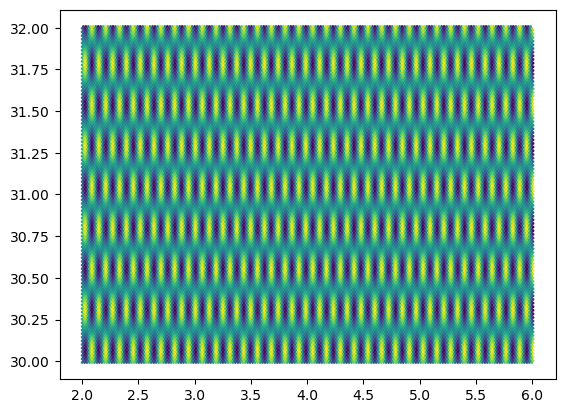

In [28]:
level = 12
ellipsoid = 'WGS84'
indexing_scheme = 'ring' # 'ring' or 'nested'
definition = 20

# Coverage box
lon_min, lon_max = 2.0, 6.0
lat_min, lat_max = 30.0, 32.0

cell_ids, _, _ = healpix_geo.nested.zone_coverage(bbox=(lon_min,lat_min,lon_max,lat_max),
                                                  depth=level, 
                                                  ellipsoid=ellipsoid)

if indexing_scheme == 'ring': 
    cell_ids = to_ring(cell_ids, depth=level)
    lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids, level, ellipsoid=ellipsoid)
elif indexing_scheme == 'nested':
    lon, lat = healpix_geo.nested.healpix_to_lonlat(cell_ids, level, ellipsoid=ellipsoid)
else:
    raise NotImplementedError("For now, indexing_scheme must be 'ring' or 'nested'")

data = np.cos(1024*lon/definition) * np.sin(256*lat/definition) + 1

plt.scatter(lon, lat, c=data, s=1)

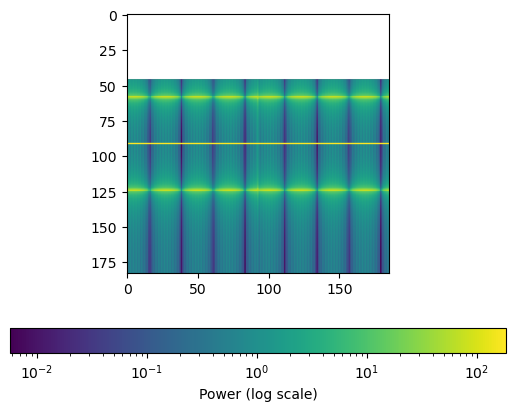

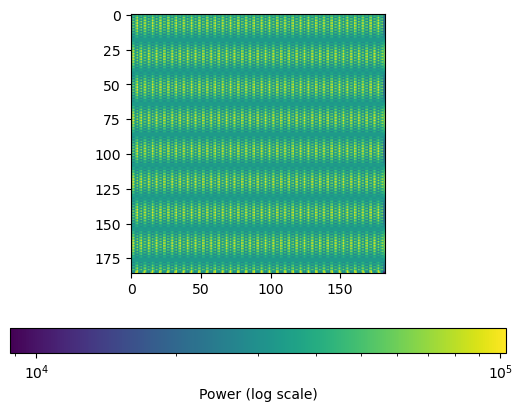

In [29]:
nu, cl = powerspectra(cell_ids, level, data, indexing_scheme=indexing_scheme, plot_2D_fft=True)

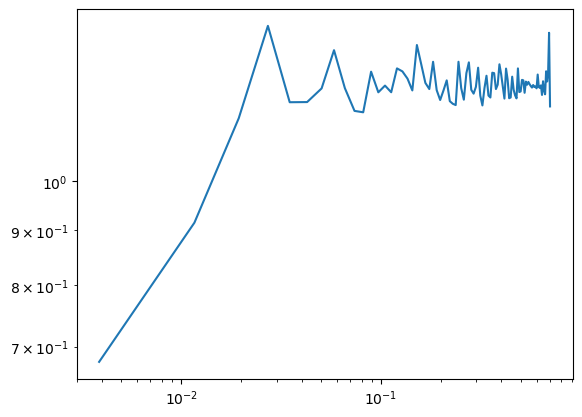

In [30]:
plt.plot(nu, cl)
plt.yscale('log')
plt.xscale('log')

In [31]:
lats = np.unique(lat)
lons = np.unique(lon)

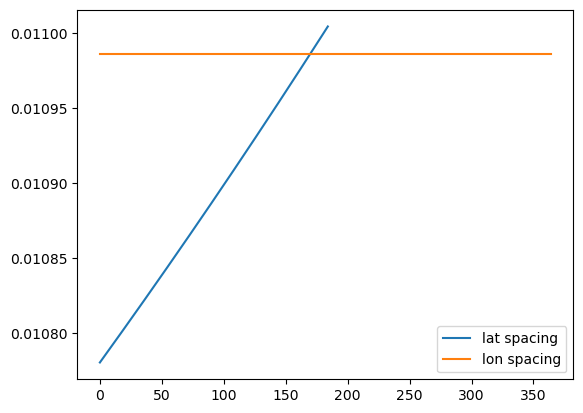

In [32]:
plt.plot(np.diff(lats), label='lat spacing')
plt.plot(np.diff(lons), label='lon spacing')
plt.legend()
plt.show()